실습 4-A (분석용): EDA 시각화 — Plotly 차트
==================================================
JupyterLab 노트북에서 셀 단위로 Plotly 차트를 만들며
정상/공격 요청을 시각적으로 비교 분석합니다.

  - 분석용 (이 파일): JupyterLab에서 셀 단위 Shift+Enter
  - 발표용 대시보드: streamlit run eda_visualization.py

각 셀은 독립적으로 실행할 수 있으며, [Setup] 셀은 반드시 먼저 실행해야 합니다.


In [1]:
# %% [Setup] 패키지 import 및 데이터 로드/전처리
import os
import re
import pandas as pd
import plotly.express as px
from urllib.parse import unquote

# Jupyter 셀 모드에서도 동작하도록 __file__ 처리
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

df = pd.read_csv(os.path.join(SCRIPT_DIR, "csic2010_requests-60k.csv"))

# 기본 특성 추출 (Streamlit 버전과 동일)
df["url_decoded"] = df["url"].apply(lambda x: unquote(str(x), encoding="latin-1"))
df["body_decoded"] = df["body"].fillna("").apply(lambda x: unquote(str(x), encoding="latin-1"))
df["full_text"] = df["url_decoded"] + " " + df["body_decoded"]
df["url_length"] = df["url_decoded"].str.len()
df["body_length"] = df["body_decoded"].str.len()
df["is_attack"] = (df["label"] == "Anomalous").astype(int)

print(f"데이터 로드: {len(df):,}건  (정상 {(df['label']=='Normal').sum():,} / "
      f"공격 {(df['label']=='Anomalous').sum():,})")
df.head()


데이터 로드: 10,000건  (정상 5,895 / 공격 4,105)


,label,method,url,http_version,host,user_agent,pragma,cache_control,accept,accept_encoding,...,content_length,connection,body,classification,url_decoded,body_decoded,full_text,url_length,body_length,is_attack
0,Anomalous,POST,/tienda1/publico/caracteristicas.jsp,HTTP/1.1,localhost:8080,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate",...,Content-Length: 5,Connection: close,idA=2,1,/tienda1/publico/caracteristicas.jsp,idA=2,/tienda1/publico/caracteristicas.jsp idA=2,36,5,1
1,Normal,GET,/tienda1/miembros/imagenes/ogono.jpg,HTTP/1.1,localhost:8080,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate",...,NaN,close,NaN,0,/tienda1/miembros/imagenes/ogono.jpg,,/tienda1/miembros/imagenes/ogono.jpg,36,0,0
2,Normal,POST,/tienda1/publico/vaciar.jsp,HTTP/1.1,localhost:8080,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate",...,Content-Length: 17,Connection: close,B2=Vaciar+carrito,0,/tienda1/publico/vaciar.jsp,B2=Vaciar+carrito,/tienda1/publico/vaciar.jsp B2=Vaciar+carrito,27,17,0
3,Normal,GET,/tienda1/index.jsp,HTTP/1.1,localhost:8080,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate",...,NaN,close,NaN,0,/tienda1/index.jsp,,/tienda1/index.jsp,18,0,0
4,Normal,GET,/tienda1/global/titulo.jsp,HTTP/1.1,localhost:8080,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate",...,NaN,close,NaN,0,/tienda1/global/titulo.jsp,,/tienda1/global/titulo.jsp,26,0,0


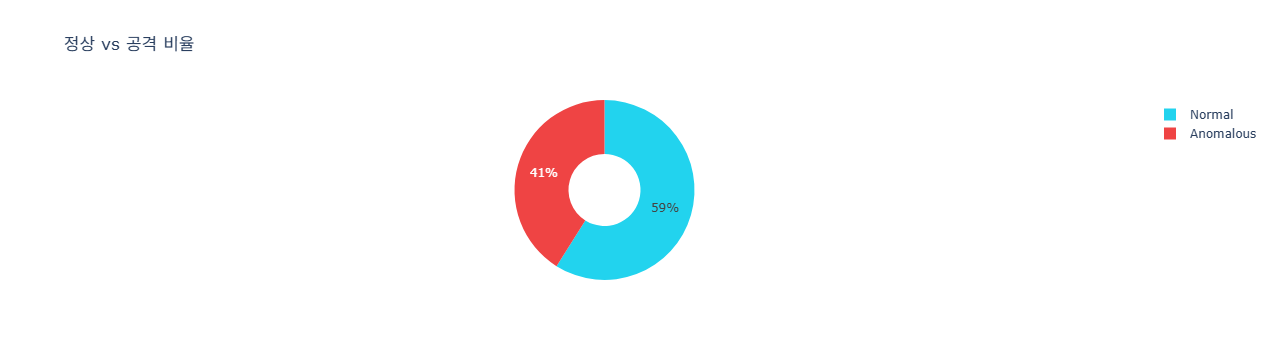

In [14]:
# %% [1] 정상 vs 공격 비율 (파이 차트)
fig = px.pie(
    values=df["label"].value_counts().values,
    names=df["label"].value_counts().index,
    title="정상 vs 공격 비율",
    color_discrete_sequence=["#22d3ee", "#ef4444"],
    hole=0.4,
)
fig.show()


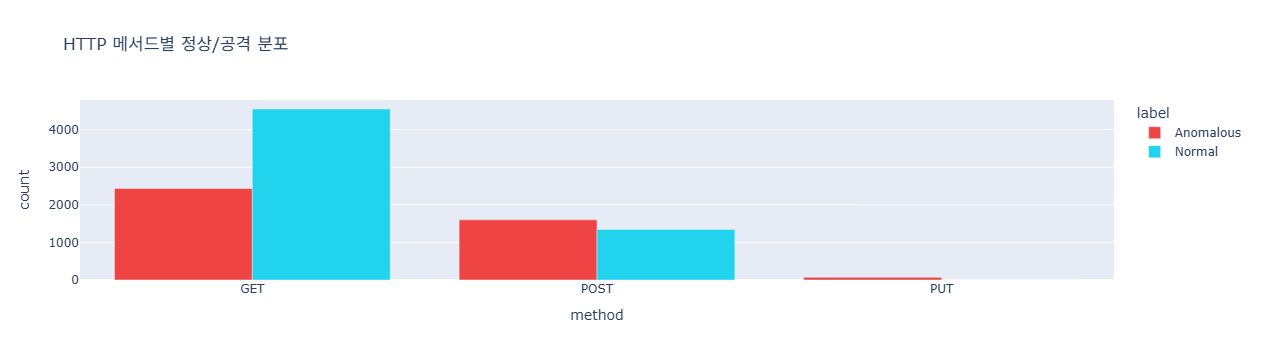

,공격 건수,전체 건수,공격 비율(%)
method,,,
GET,2434,6984,34.9
POST,1600,2945,54.3
PUT,71,71,100.0


In [15]:
# %% [2] HTTP 메서드별 정상/공격 분포 (그룹 막대)
cross = pd.crosstab(df["method"], df["label"]).reset_index()
cross_melted = cross.melt(id_vars="method", var_name="label", value_name="count")

fig = px.bar(
    cross_melted,
    x="method", y="count", color="label",
    title="HTTP 메서드별 정상/공격 분포",
    barmode="group",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.show()

# 메서드별 공격 비율 표
method_attack = df.groupby("method")["is_attack"].agg(["sum", "count"])
method_attack["attack_ratio(%)"] = method_attack["sum"] / method_attack["count"] * 100
method_attack.columns = ["공격 건수", "전체 건수", "공격 비율(%)"]
method_attack.round(1)


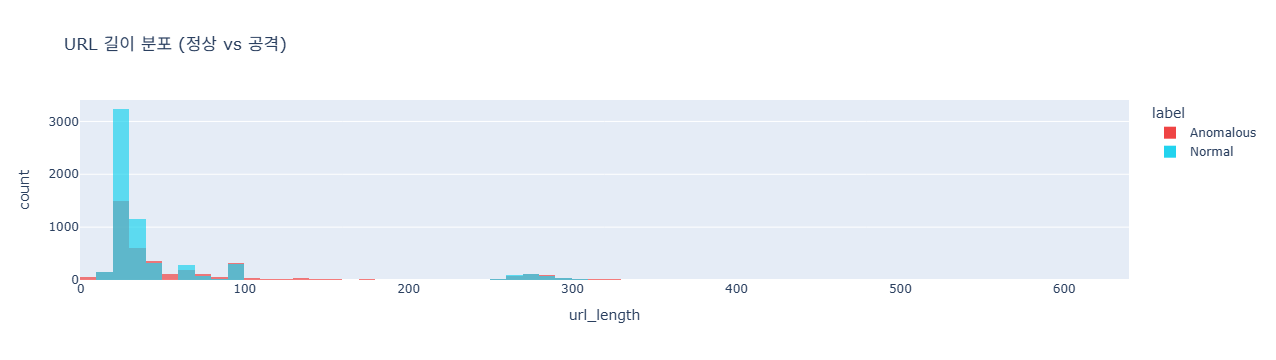

In [16]:
# %% [3] URL 길이 히스토그램 (정상 vs 공격)
fig = px.histogram(
    df,
    x="url_length",
    color="label",
    title="URL 길이 분포 (정상 vs 공격)",
    barmode="overlay",
    opacity=0.7,
    nbins=100,
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.show()


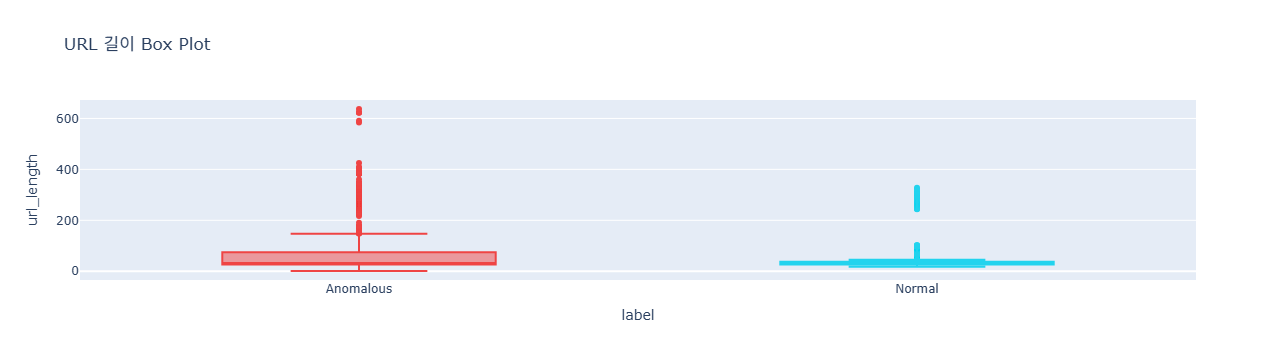

In [17]:
# %% [4] URL 길이 Box Plot
fig = px.box(
    df,
    x="label", y="url_length",
    color="label",
    title="URL 길이 Box Plot",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.update_layout(showlegend=False)
fig.show()


POST 요청 수: 2,945건


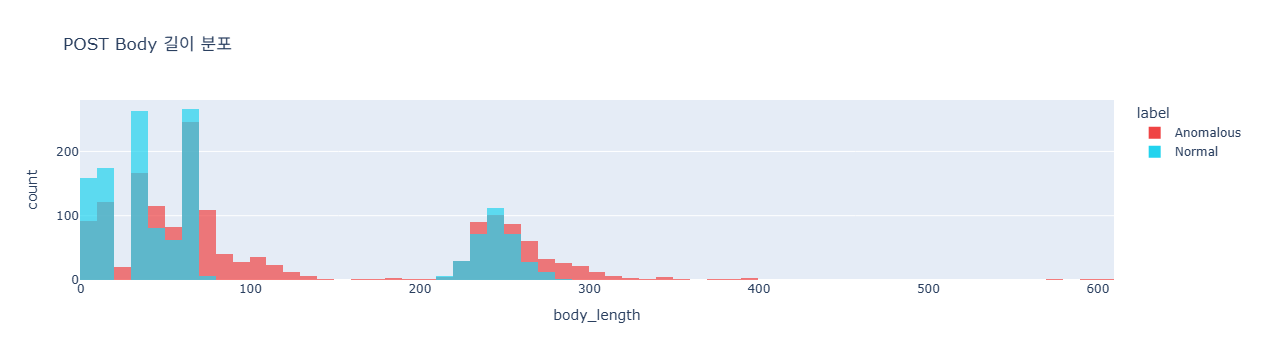

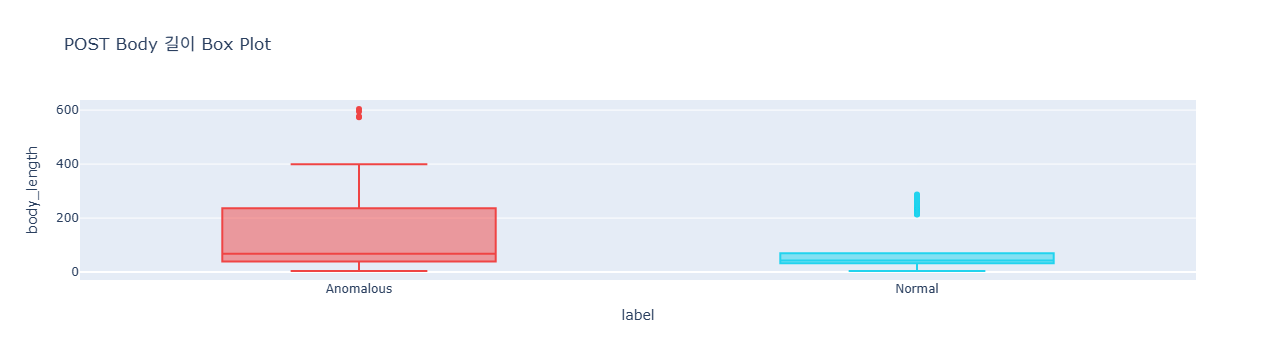

In [18]:
# %% [5] POST 본문 길이 분석 (히스토그램 + Box Plot)
post_df = df[df["method"] == "POST"].copy()
print(f"POST 요청 수: {len(post_df):,}건")

fig = px.histogram(
    post_df,
    x="body_length",
    color="label",
    title="POST Body 길이 분포",
    barmode="overlay",
    opacity=0.7,
    nbins=80,
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.show()

fig = px.box(
    post_df,
    x="label", y="body_length",
    color="label",
    title="POST Body 길이 Box Plot",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.update_layout(showlegend=False)
fig.show()


In [19]:
# %% [6] URL/Body 길이 통계 요약
length_stats = df.groupby("label")[["url_length", "body_length"]].agg(
    ["mean", "median", "max"]
).round(0)
length_stats


url_length             body_length            
                mean median  max        mean median  max
label                                                   
Anomalous       73.0   32.0  637        47.0    0.0  604
Normal          50.0   29.0  328        20.0    0.0  287

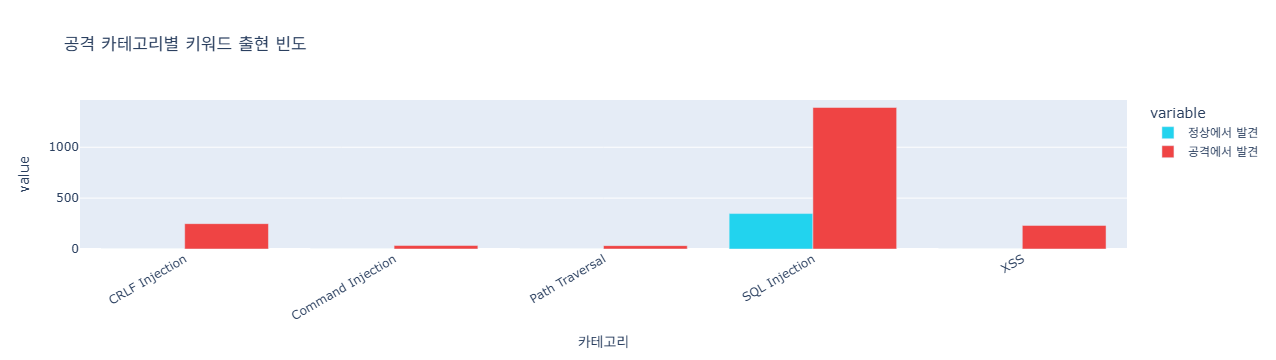

In [20]:
# %% [7] 공격 카테고리별 키워드 출현 빈도
attack_categories = {
    "SQL Injection": ["'", "select", "union", "drop", "insert",
                      "delete", "update", "or '", "1=1", "--"],
    "XSS": ["<script", "alert(", "onerror", "<iframe",
            "<img", "javascript:", "onfocus"],
    "Path Traversal": ["../", "..\\", "/etc/passwd", "/etc/shadow"],
    "Command Injection": ["; ", "|", "&&", "/bin/", "cat ",
                          "rm ", "wget", "curl"],
    "CRLF Injection": ["%0d", "%0a", "\\r\\n"],
}

results = []
for category, keywords in attack_categories.items():
    for kw in keywords:
        normal_count = df[df["label"] == "Normal"]["full_text"].str.contains(
            re.escape(kw), case=False, na=False
        ).sum()
        attack_count = df[df["label"] == "Anomalous"]["full_text"].str.contains(
            re.escape(kw), case=False, na=False
        ).sum()
        results.append({
            "카테고리": category,
            "키워드": kw,
            "정상에서 발견": int(normal_count),
            "공격에서 발견": int(attack_count),
            "공격 집중도(%)": round(attack_count / max(normal_count + attack_count, 1) * 100, 1),
        })

result_df = pd.DataFrame(results)

cat_summary = result_df.groupby("카테고리").agg({
    "정상에서 발견": "sum",
    "공격에서 발견": "sum",
}).reset_index()

fig = px.bar(
    cat_summary.melt(id_vars="카테고리"),
    x="카테고리", y="value", color="variable",
    title="공격 카테고리별 키워드 출현 빈도",
    barmode="group",
    color_discrete_map={
        "정상에서 발견": "#22d3ee",
        "공격에서 발견": "#ef4444",
    },
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()


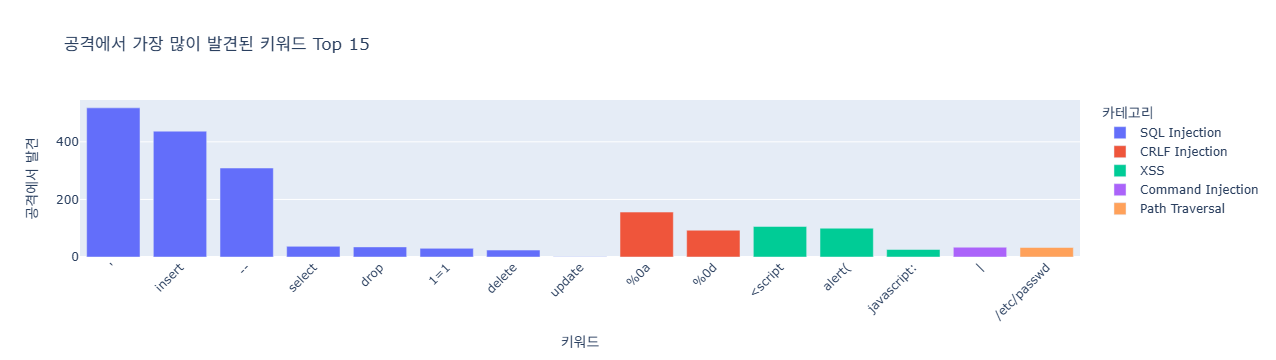

In [21]:
# %% [8] 공격에서 가장 많이 발견된 키워드 Top 15
top_keywords = result_df.nlargest(15, "공격에서 발견")

fig = px.bar(
    top_keywords,
    x="키워드", y="공격에서 발견",
    color="카테고리",
    title="공격에서 가장 많이 발견된 키워드 Top 15",
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()


In [22]:
# %% [9] 키워드별 상세 표 (공격 빈도순 정렬)
result_df.sort_values("공격에서 발견", ascending=False).head(20)


,카테고리,키워드,정상에서 발견,공격에서 발견,공격 집중도(%)
0,SQL Injection,',19,518,96.5
4,SQL Injection,insert,327,437,57.2
9,SQL Injection,--,0,309,100.0
30,CRLF Injection,%0a,0,156,100.0
10,XSS,<script,0,106,100.0
11,XSS,alert(,0,100,100.0
29,CRLF Injection,%0d,0,93,100.0
1,SQL Injection,select,0,37,100.0
3,SQL Injection,drop,2,35,94.6
22,Command Injection,|,0,34,100.0


In [23]:
# %% [10] 정상 vs 공격 HTTP 요청 직접 비교
# 인덱스를 바꿔가며 다양한 요청을 살펴보세요.
NORMAL_IDX = 0       # 0 ~ 정상 요청 마지막
ANOMALOUS_IDX = 0    # 0 ~ 공격 요청 마지막

normal_df = df[df["label"] == "Normal"].reset_index(drop=True)
anomalous_df = df[df["label"] == "Anomalous"].reset_index(drop=True)

print("✅ 정상 요청 (Normal)")
print("-" * 70)
n = normal_df.iloc[NORMAL_IDX]
print(f"  메서드: {n['method']}")
print(f"  URL  : {n['url_decoded']}")
if n["body_decoded"]:
    print(f"  Body : {n['body_decoded']}")

print()
print("🚨 공격 요청 (Anomalous)")
print("-" * 70)
a = anomalous_df.iloc[ANOMALOUS_IDX]
print(f"  메서드: {a['method']}")
print(f"  URL  : {a['url_decoded']}")
if a["body_decoded"]:
    print(f"  Body : {a['body_decoded']}")


✅ 정상 요청 (Normal)
----------------------------------------------------------------------
  메서드: GET
  URL  : /tienda1/miembros/imagenes/ogono.jpg

🚨 공격 요청 (Anomalous)
----------------------------------------------------------------------
  메서드: POST
  URL  : /tienda1/publico/caracteristicas.jsp
  Body : idA=2


In [24]:
# %% [11] 키워드 검색 — 임의의 키워드를 포함한 요청 찾기
# 키워드를 바꿔가며 어떤 요청에 패턴이 나타나는지 직접 확인하세요.
SEARCH_KEYWORD = "select"   # 예: "<script", "../", "' OR", "union", "alert("

full_text = df["url"].fillna("") + " " + df["body"].fillna("")
matched = df[full_text.str.contains(SEARCH_KEYWORD, case=False, na=False)]

n_normal = (matched["label"] == "Normal").sum()
n_attack = (matched["label"] == "Anomalous").sum()
print(f"'{SEARCH_KEYWORD}' 포함 요청: {len(matched):,}건 "
      f"(정상 {n_normal} / 공격 {n_attack})")
print()

for _, row in matched.head(5).iterrows():
    icon = "✅" if row["label"] == "Normal" else "🚨"
    decoded = unquote(str(row["url"]), encoding="latin-1")
    print(f"{icon} [{row['label']:<10s}] {row['method']:<5s} {decoded[:120]}")


'select' 포함 요청: 37건 (정상 0 / 공격 37)

🚨 [Anomalous ] GET   /tienda1/miembros/editar.jsp?modo=registro&login=boinnard&password=alARgUEZ&nombre=Celinda&apellidos=Alberti';+DROP+TABL
🚨 [Anomalous ] POST  /tienda1/publico/vaciar.jsp
🚨 [Anomalous ] POST  /tienda1/publico/autenticar.jsp
🚨 [Anomalous ] GET   /tienda1/publico/pagar.jsp?modo=insertar&precio=7744&B1=';+DROP+TABLE+usuarios;+SELECT+*+FROM+datos+WHERE+nombre+LIKE+'%
🚨 [Anomalous ] POST  /tienda1/publico/registro.jsp


In [25]:
# %% [요약] EDA 핵심 발견
print("=" * 70)
print("  EDA 핵심 발견")
print("=" * 70)
print("  발견 1. 공격 요청의 URL이 평균적으로 더 길다")
print("  발견 2. SQL/XSS/Path Traversal 키워드가 공격에 집중적으로 나타남")
print("  발견 3. 개별 공격 유형 라벨은 없음 (정상/비정상만 구분)")
print("  발견 4. 텍스트에서 1교시 학습 패턴이 직접 확인됨!")


  EDA 핵심 발견
  발견 1. 공격 요청의 URL이 평균적으로 더 길다
  발견 2. SQL/XSS/Path Traversal 키워드가 공격에 집중적으로 나타남
  발견 3. 개별 공격 유형 라벨은 없음 (정상/비정상만 구분)
  발견 4. 텍스트에서 1교시 학습 패턴이 직접 확인됨!
